                          Лабораторный журнал №5: "H+, or how to build a perfect human"

1. Сначала необходимо установить и загрузить plink для преобразования файла:

In [ ]:
wget https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20250819.zip
unzip plink_linux_x86_64_20250819.zip
chmod +x plink

Далее выполняем преобразования файла:

In [ ]:
./plink --23file SNP_raw_v4_Full_20170514175358.txt. \
  --recode vcf \
  --out snps_clean \
  --output-chr MT \
  --snps-only just-acgt

Проверяем, что файл корректен:

In [ ]:
head snps_clean.vcf

##fileformat=VCFv4.2
##fileDate=20260426
##source=PLINKv1.9
##contig=<ID=1,length=249218993>
##contig=<ID=2,length=243048761>
##contig=<ID=3,length=197833759>
##contig=<ID=4,length=190939666>
##contig=<ID=5,length=180696890>
##contig=<ID=6,length=170919471>
##contig=<ID=7,length=159119221>

Удалим позиции 0/0, которые идентичны референсным, чтобы оставить только варианты:

bcftools view -i 'GT!="0/0"' snps_clean.vcf -o snps_variable.vcf

2. Определение пола. С помощью веб-инструментов мы уже выполнили анализ Y-хромосомы. Анализ прошел успешно, значит, в образце имеется Y-хромосома, следовательно, это мужчина. Но для официальной проверки мы дополнительно посчитаем число SNP для Y и X-хромосомы, что докажет их наличие в образце.

In [ ]:
grep -w X SNP_raw_v4_Full_20170514175358.txt | wc -l

19586

In [ ]:
grep -w Y SNP_raw_v4_Full_20170514175358.txt | wc -l

2129

Таким образом, найденные SNP и в обеих хромосомах подтверждают, что испытуемый, чей образец мы исследуем, имеет генотип (XY), следовательно, мужской пол.

**Далее в рамках задания "Who are we?" начнём определение фенотипа по имеющимся данным, остановимся для начала на основных характеристиках внешности.**

3. Далее определим цвет глаз с помощью системы прогнозирования цвета глаз и кожи на основе 8 однонуклеотидных полиморфизмов.

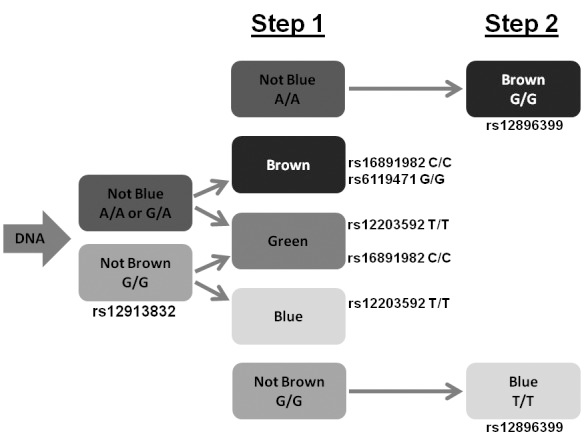

Сначала с помощью rs12913832 (HERC2) цвет глаз определяется как не карий (то есть зеленый или голубой) или не голубой (то есть карий или зеленый).

In [ ]:
grep rs12913832 SNP_raw_v4_Full_20170514175358.txt

rs12913832      15      28365618        AG

Получен генотип A/G, что говорит о том, что цвет глаз не голубой.

Для уточнения цвета глаз проверяем другие однонуклеотидные полиморфизмы:

 rs16891982 в гене SLC45A2

rs6119471 в гене ASIP

rs12203592 (IRF4)

rs12896399 (SLC24A4)

In [ ]:
grep rs16891982 SNP_raw_v4_Full_20170514175358.txt
grep rs6119471 SNP_raw_v4_Full_20170514175358.txt
grep rs12203592 SNP_raw_v4_Full_20170514175358.txt
grep rs12896399 SNP_raw_v4_Full_20170514175358.txt

rs16891982      5       33951693        CG

по  rs6119471 ничего не найдено

rs12203592      6       396321  CT

rs12896399      14      92773663        GG

Данная проверка не дала однозначных результатов, так как мы не получали генотипы, изображенные на схеме. Но наиболее вероятно, что глаза зеленые или зелено-карие (промежуточный цвет).

Поэтому мы решили определить цвет глаз с помощью другой системы - HIrisPlex.

Проверим генотип во всех значимых точках для этой системы:

In [ ]:
grep rs1800407 SNP_raw_v4_Full_20170514175358.txt
rs1800407       15      28230318        CC
grep rs12896399 SNP_raw_v4_Full_20170514175358.txt
rs12896399      14      92773663        GG
grep rs16891982 SNP_raw_v4_Full_20170514175358.txt
rs16891982      5       33951693        CG
grep rs1393350 SNP_raw_v4_Full_20170514175358.txt
rs1393350       11      89011046        AG
grep rs12203592 SNP_raw_v4_Full_20170514175358.txt
rs12203592      6       396321  CT

![image.png](attachment:b1fe7374-fa45-40eb-b0a5-82f1019aac6b.png)

The IrisPlex System по загруженным данным показала большую вероятность голубого цвета глаз.

Для подтверждения данной информации мы выполнили проверку по первой системе (посмотрели в rs12896399 и rs12203592 важные для голубого цвета глаз).

In [ ]:
grep rs12896399 SNP_raw_v4_Full_20170514175358.txt
rs12896399      14      92773663        GG
grep rs12203592 SNP_raw_v4_Full_20170514175358.txt
rs12203592      6       396321  CT

Данный анализ показал полное несоответствие генотипов для голубого цвета глаз, что подтверждает наш первичный анализ и вывод о том, что у *владельца исследуемого нами генотипа зеленый или промежуточный от зеленого (зелено-карий) цвет глаз.*

4. С помощью HIrisPlex System определили полный набор внешних данных испытуемого (тон кожи, цвет волос)

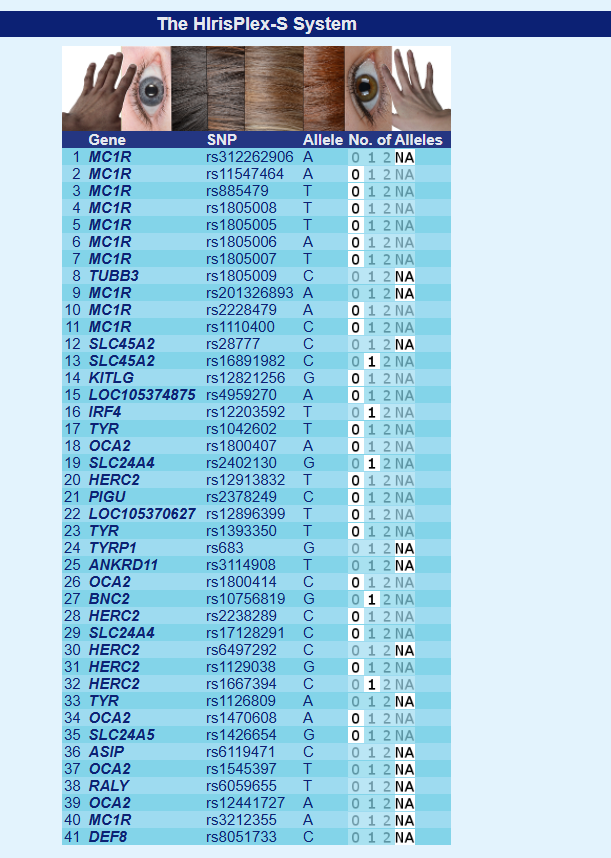

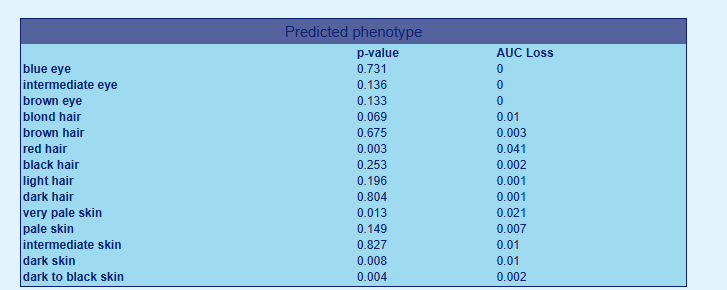

Теперь для уточнения результатов воспользуемся 8-плексной системой, в которой используются шесть однонуклеотидных полиморфизмов: The skin color prediction of the 8-plex system utilizes six SNPs (Figure 1). In a similar manner to the eye color, the skin color is binned into three groups: light, medium, and dark. The skin-color predictor utilizes five SNPs to predict a lighter skin color and one to predict darker shades. Skin coloration is predicted in an elimination process. Non-dark skin color (ie, light or medium) is predicted by any two of the following alleles: G/G at rs12913832, G/G at rs16891982, A/A at rs1426654, T/T at rs1545397, or A/A at rs885479. Light skin color is predicted by more stringent conditions: G/G at rs12913832, plus G/G at rs16891982, and A/A at rs1426654. Non-light skin color (ie, medium or dark) is predicted by G/G at rs6119471.

In [ ]:
grep rs12913832 SNP_raw_v4_Full_20170514175358.txt
rs12913832      15      28365618        AG
grep rs16891982 SNP_raw_v4_Full_20170514175358.txt
rs16891982      5       33951693        CG
grep rs1426654 SNP_raw_v4_Full_20170514175358.txt
rs1426654       15      48426484        AA
grep rs1545397 SNP_raw_v4_Full_20170514175358.txt
grep rs885479 SNP_raw_v4_Full_20170514175358.txt
rs885479        16      89986154        GG
grep rs6119471 SNP_raw_v4_Full_20170514175358.txt
ничего не найдено

Определение по данной системе не дало однозначных результатов, но подтвердило утверждение о не тёмном цвете кожи, значит, он светлый или промежуточный, вероятнее всего ближе к светлому.

Таким образом, по результатам определения цвета кожи на основе двух систем HIrisPlex System и 8-плексной системы, можно сделать вывод о том, что данные соответствуют промежуточному цвету кожи, приближенному к светлой коже. Цвет волос же соответствует темно-коричневому цвету.

Следовательно, по результатам анализа получен следующий фенотип: зеленые (или зелено-карие) глаза, светлая кожа и темно-коричневый цвет волос.

| Trait               | SNP       | Genotype | Interpretation            |
| ------------------- | --------- | -------- | ------------------------- |
| Caffeine metabolism | rs762551  | AA       | Fast metabolizer          |
| Lactose tolerance   | rs4988235 | GG       | Likely lactose intolerant |
| Alcohol metabolism  | rs671     | GG       | Normal metabolism         |
| Muscle performance  | rs1815739 | CC       | Power/sprint type         |
| Skin pigmentation   | rs1426654 | AA       | Light pigmentation        |


5. Аннотация однонуклеотидных полиморфизмов с использованием веб-инструмента  VEP (Variant Effect Predictor) http://grch37.ensembl.org/Homo_sapiens/Tools/VEP

Ниже представлены все необходимые параметры, которые важно настроить для полноценного анализа.

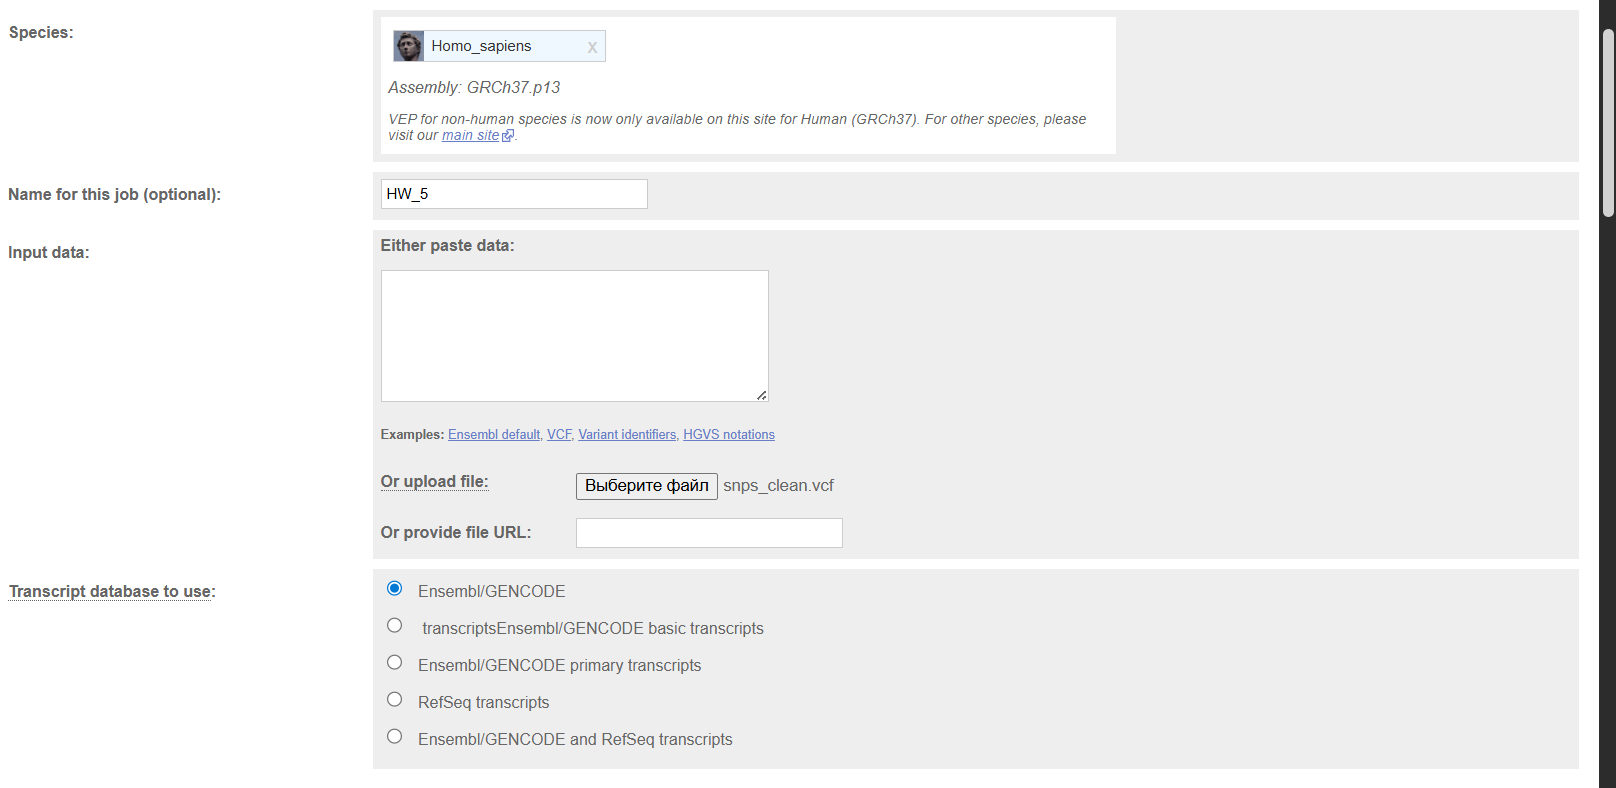

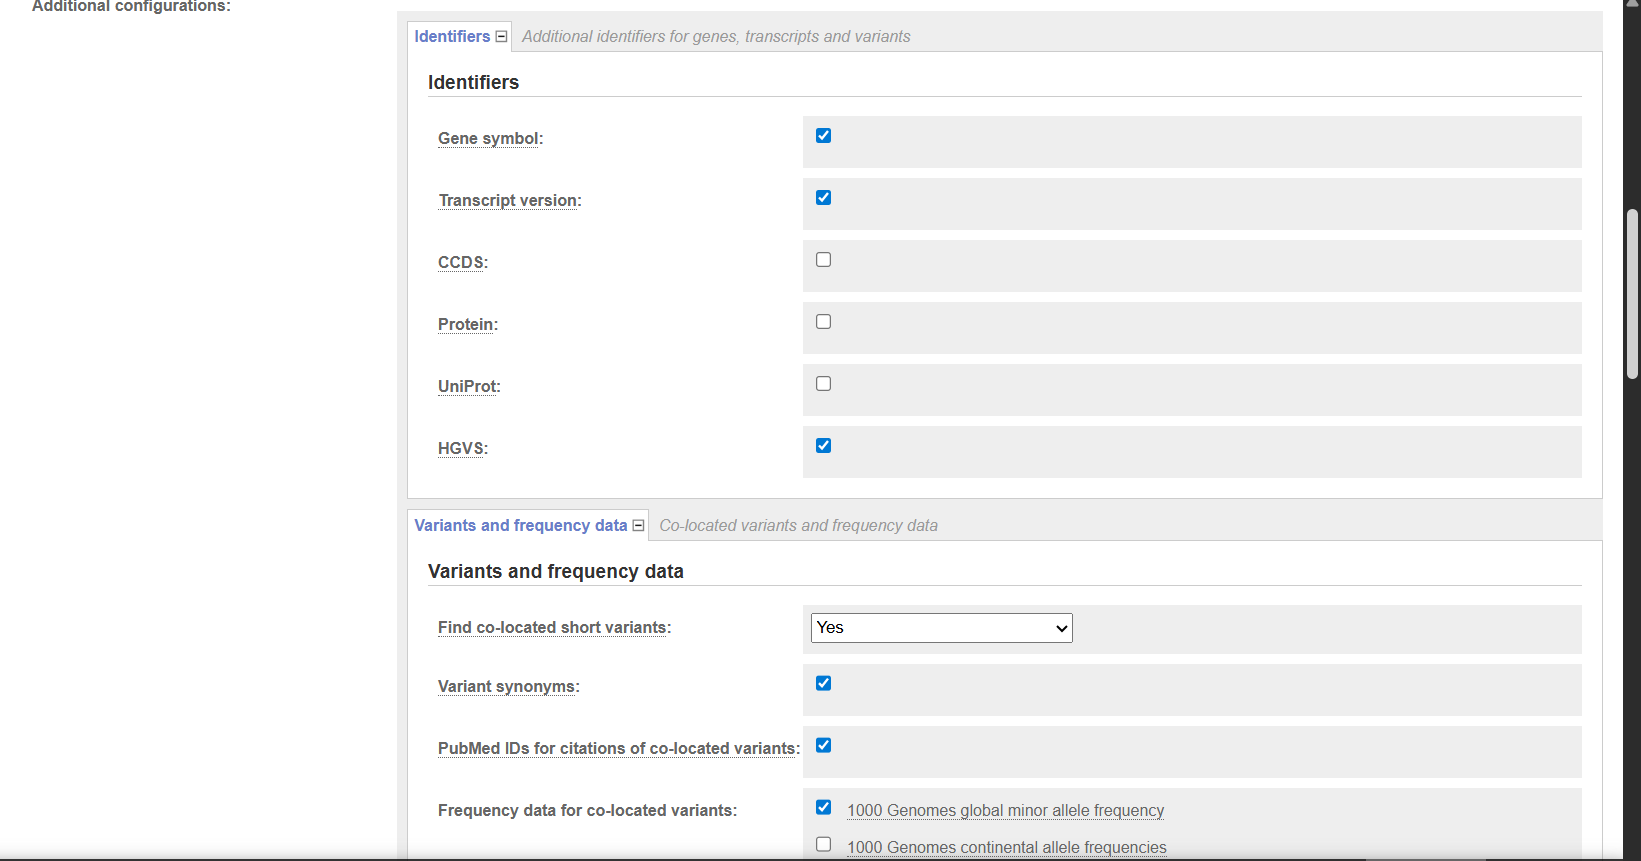

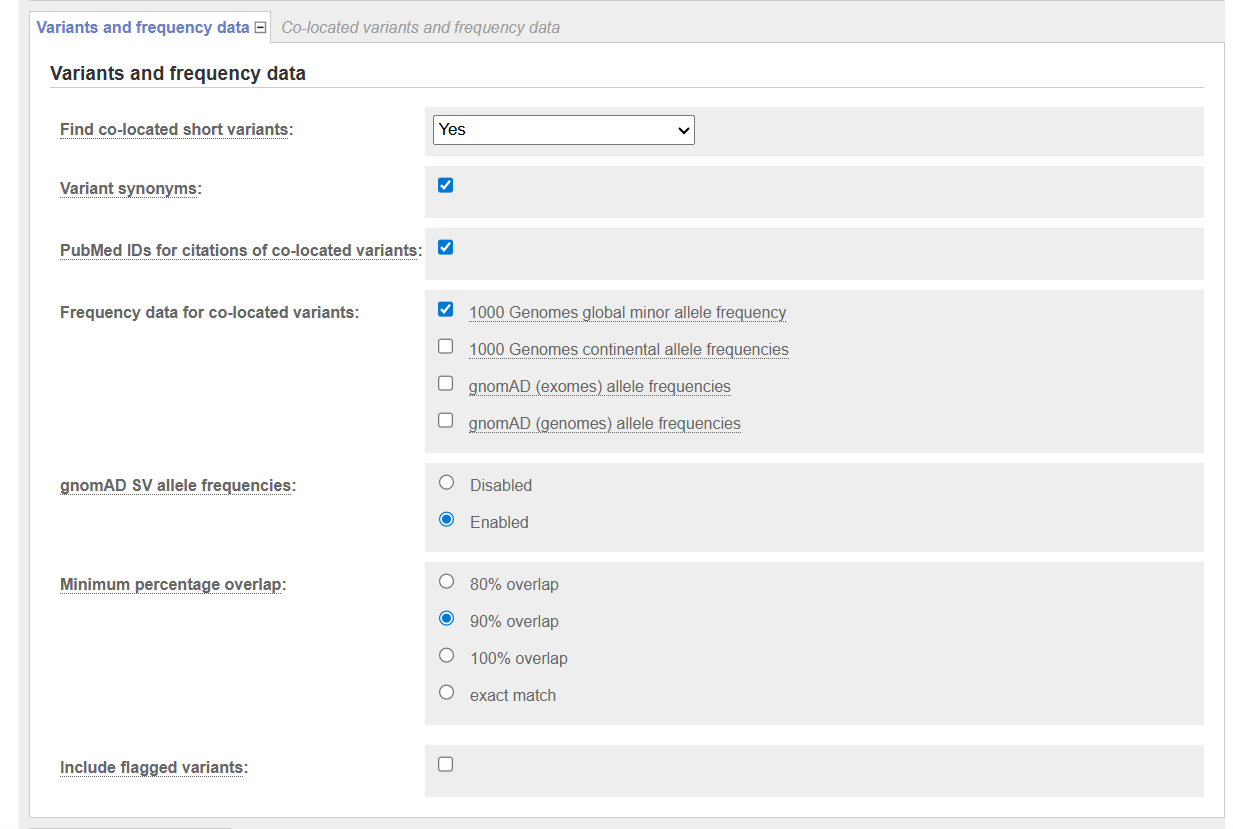

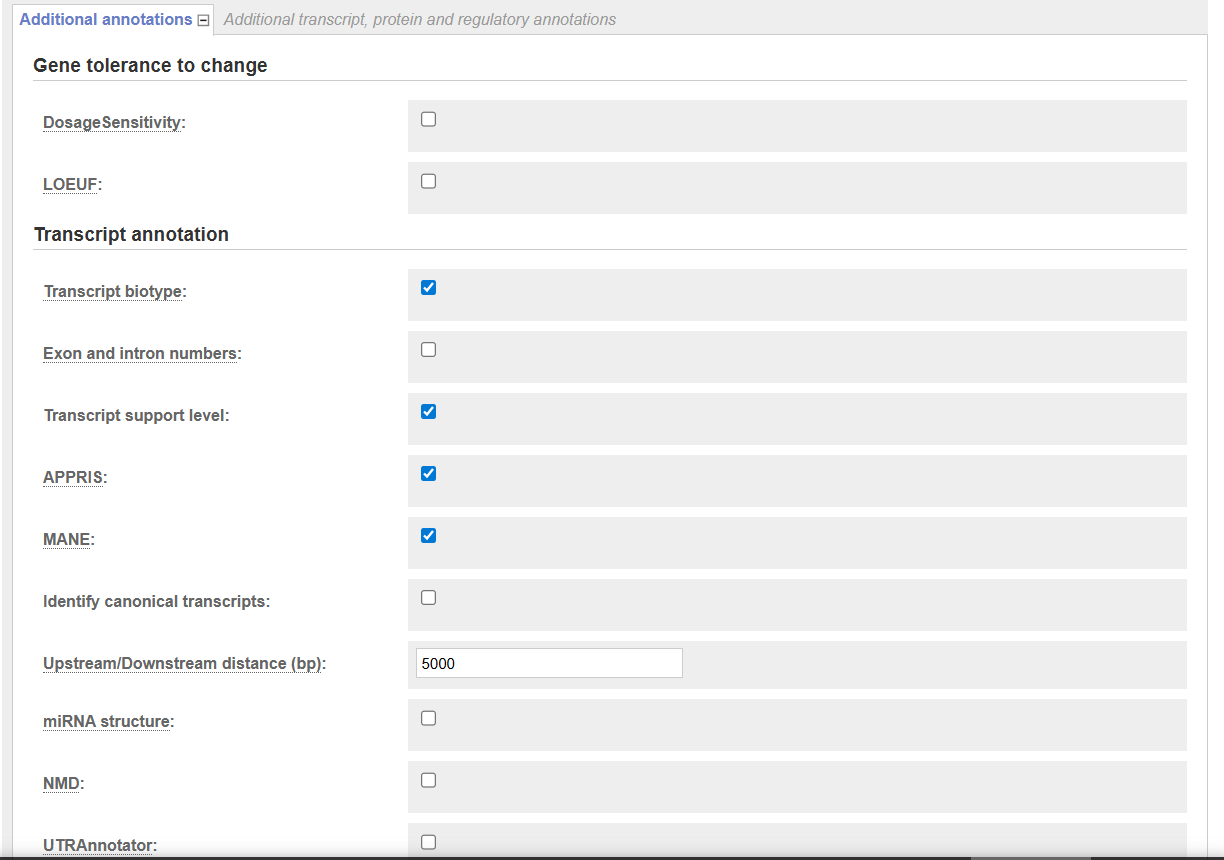

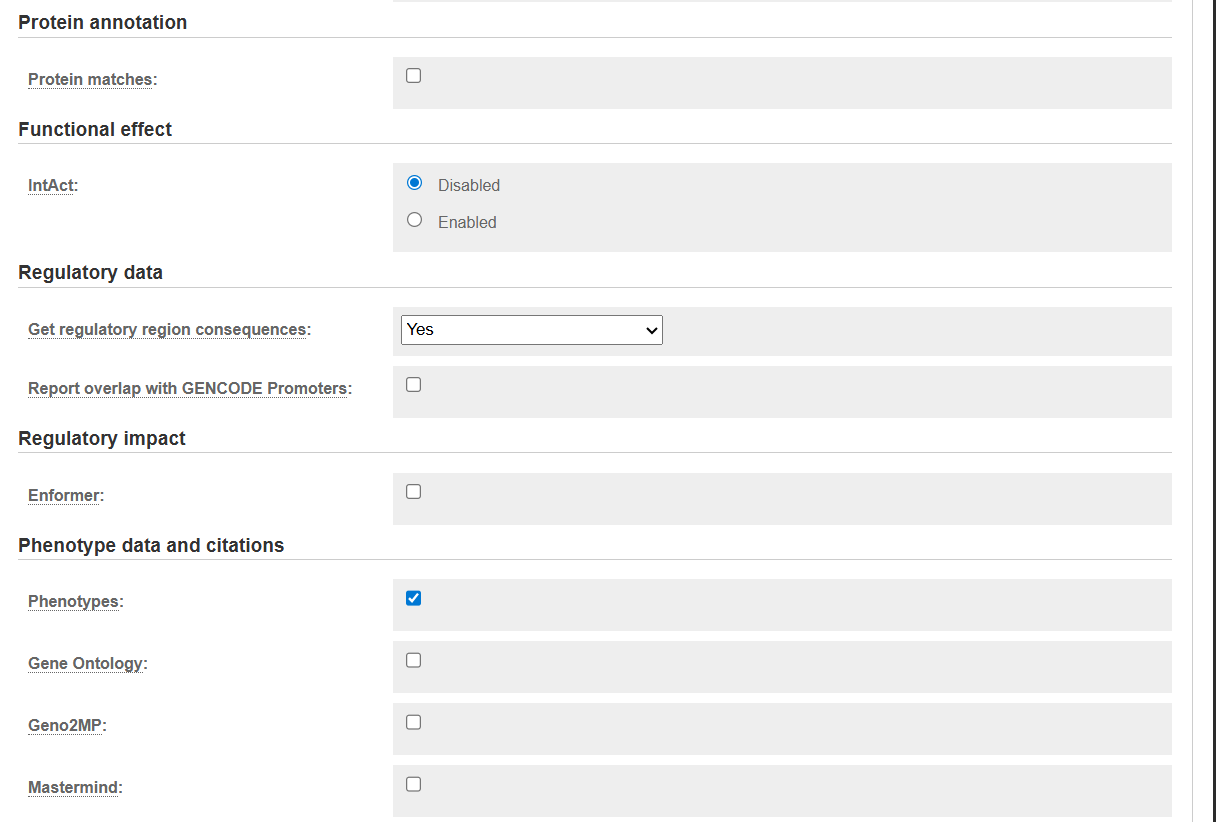

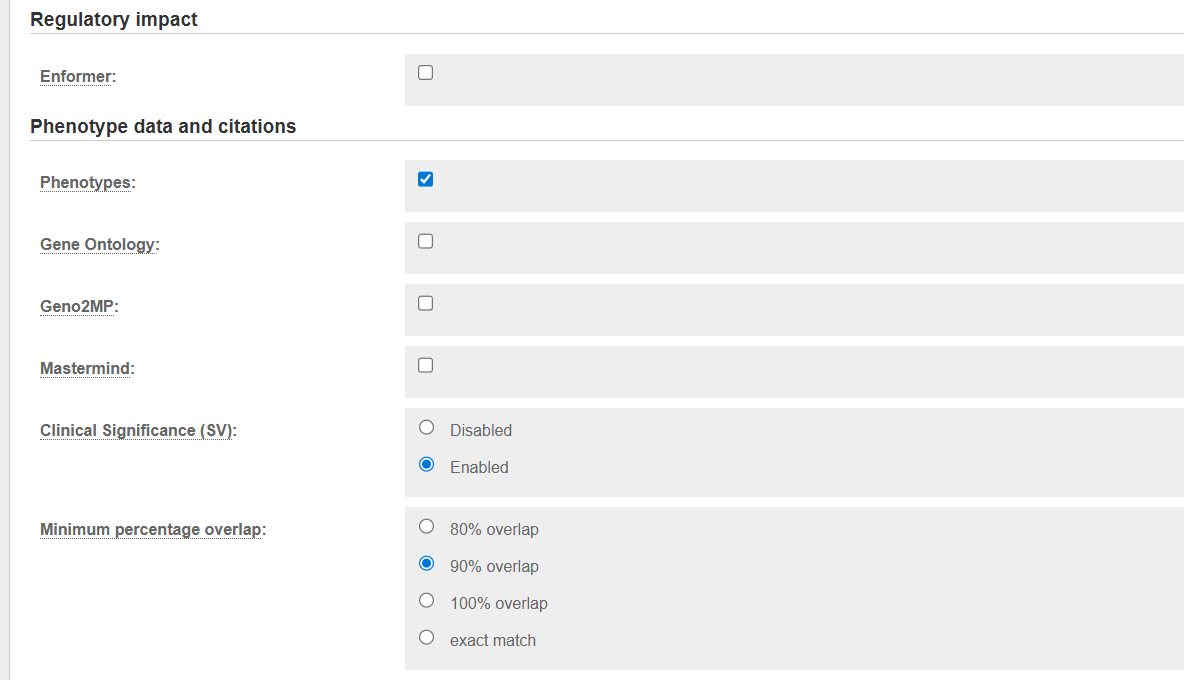

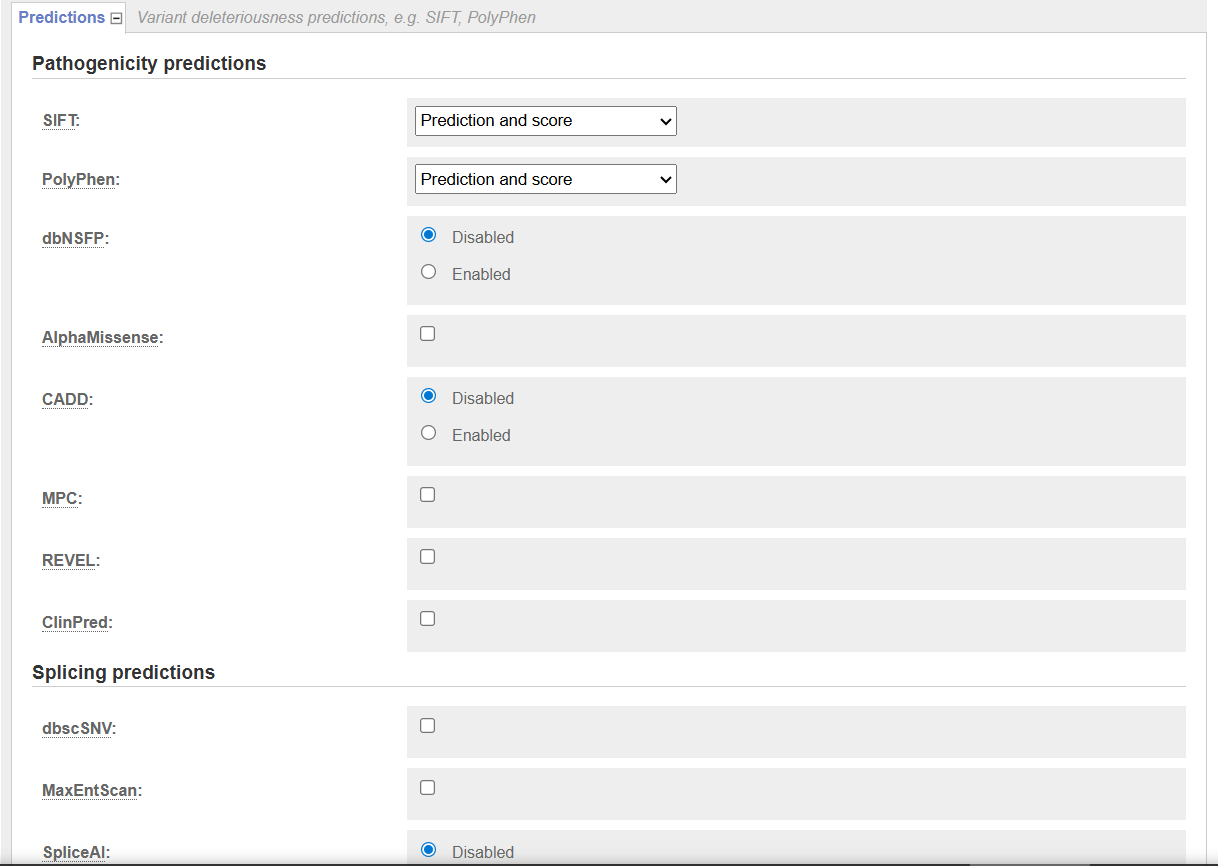

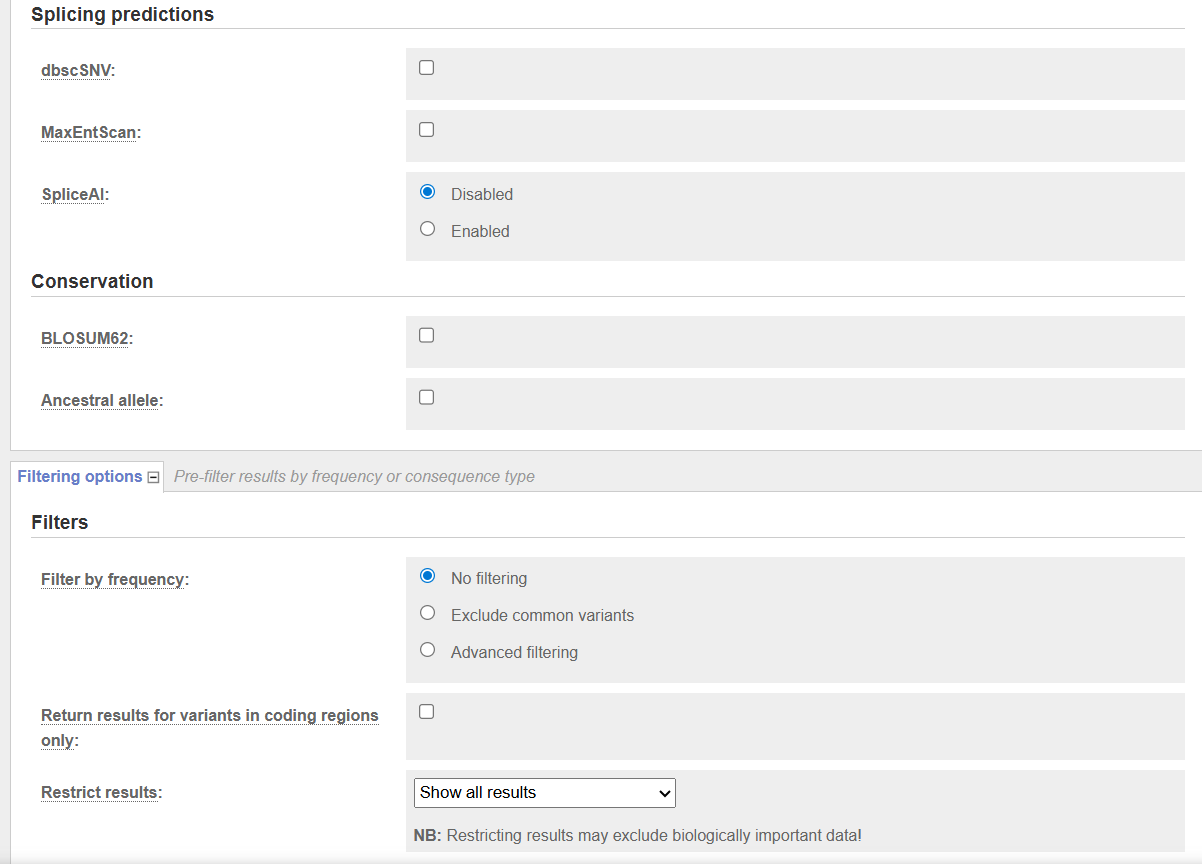

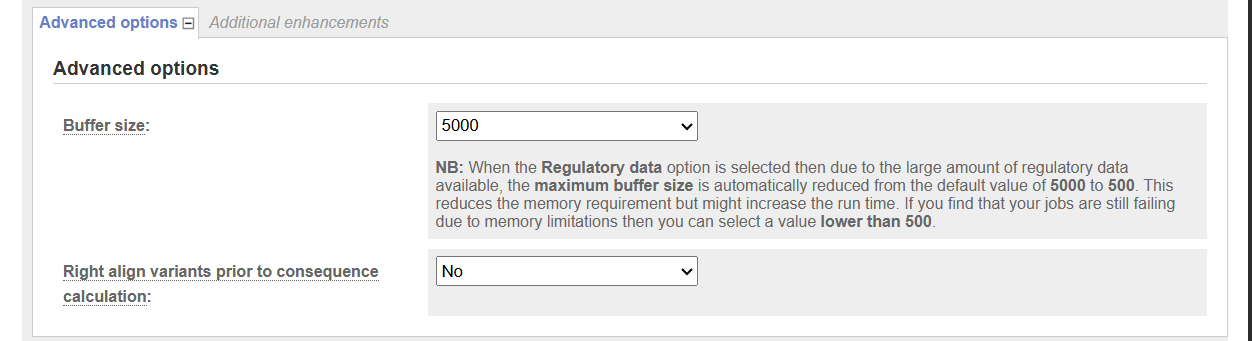

По результатам работы VEP получили файл VEP_results.txt, из которого далее извлечем все клинически значимые SNP.

Сначала необходимо определить номер строки с названием "CLIN_SIG", для этого выводим все заголовки и по результатам видим номер - "38.CLIN_SIG".

In [ ]:
grep "^#Uploaded_variation" VEP_results.txt | tr '\t' '\n' | nl

Затем получаем необходимые варианты и выводим их в таблицу risk_snps.tsv

In [ ]:
awk -F'\t' '$38!="-"' VEP_results.txt | grep risk_factor | cut -f 1-3 | sort | uniq > risk_snps.tsv

i6058143        1:161479745-161479745   G
rs1024611       17:32579788-32579788    G
rs1169288       12:121416650-121416650  C
rs12150220      17:5485367-5485367      T
rs1801274       1:161479745-161479745   G
rs1801275       16:27374400-27374400    G
rs2073658       1:161010762-161010762   T
rs2281845       1:201081943-201081943   T
rs460897        1:196716319-196716319   T
rs5051  1:230849872-230849872   T
rs5174  1:53712727-53712727     T
rs61747071      16:53720436-53720436    T
rs6265  11:27679916-27679916    T
rs6504649       17:48437456-48437456    G
rs699   1:230845794-230845794   G

Далее проводим анализ вариантов с помощью dbSNP и составляем таблицу.